# 매장별 유동인구 분배

## 분배 가중치 선정

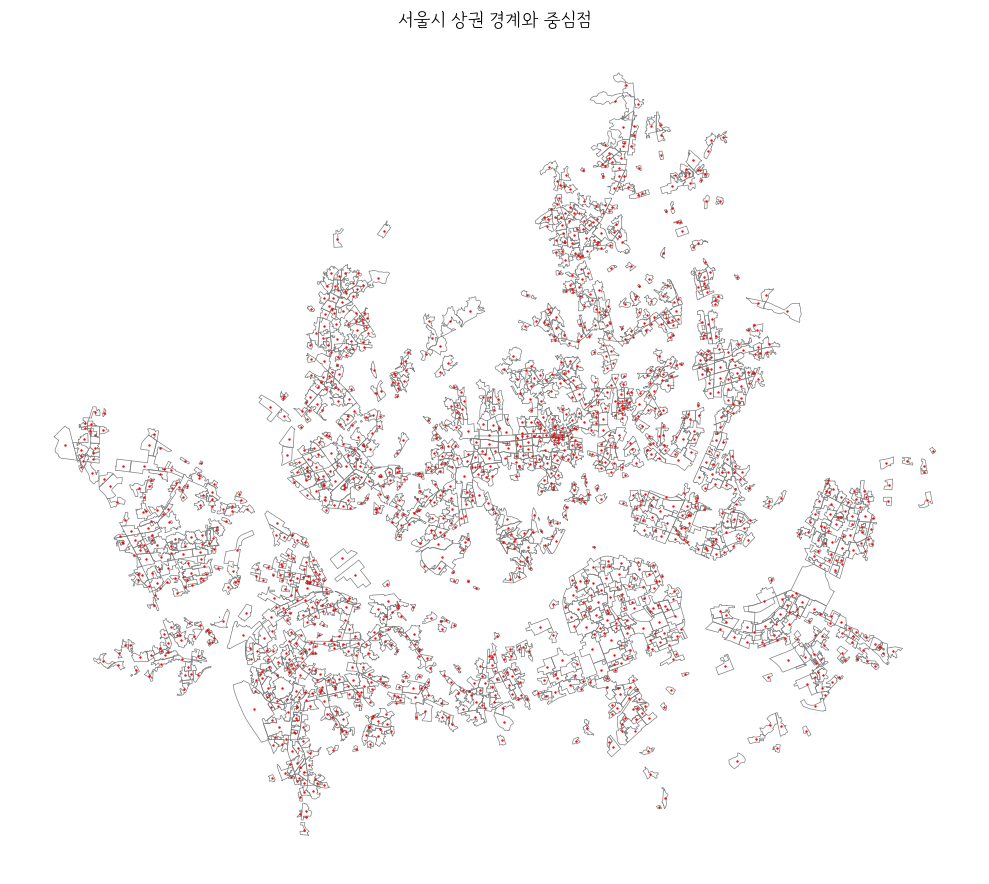

In [27]:
# 상권 중심점 계산

# 상권 중심점으로부터 카페의 거리 계산
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 상권 Polygon 데이터 로드
gdf_commercial = gpd.read_file(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\상권_행정구역_구분\서울시 상권분석서비스(영역-상권).shp')# encoding='euc-kr')

# 중심점 계산
gdf_commercial['centroid'] = gdf_commercial['geometry'].centroid
gdf_commercial['상권_lat'] = gdf_commercial['centroid'].y
gdf_commercial['상권_lon'] = gdf_commercial['centroid'].x

df_centroids = gdf_commercial[['TRDAR_CD', '상권_lat', '상권_lon']]
df_centroids.head(4)

# 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 1. 상권 경계 그리기
gdf_commercial.plot(ax=ax, edgecolor='gray', facecolor='none', linewidth=0.5)

# 2. 중심점 그리기
gdf_commercial.set_geometry('centroid').plot(ax=ax, color='red', markersize=0.5)

# 타이틀 및 스타일 설정
ax.set_title("서울시 상권 경계와 중심점", fontsize=15)
ax.axis('off')
plt.tight_layout()
# plt.show()


In [28]:
# 상권의 중심점에 카페가 가까울수록 유동인구가 많다고 가정
df_centroids.columns = ['TRDAR_CD', '상권_lat', '상권_lon']
df_centroids = df_centroids.copy()
import numpy as np
import pandas as pd
df_store = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_상권_매핑_데이터_중복제거.csv')
df_store['TRDAR_CD'] = df_store['TRDAR_CD'].astype(str)
df_centroids['TRDAR_CD'] = df_centroids['TRDAR_CD'].astype(str)
df_store = df_store.merge(df_centroids, on='TRDAR_CD', how='left')

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름 (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    d_phi = np.radians(lat2 - lat1)
    d_lambda = np.radians(lon2 - lon1)

    a = np.sin(d_phi/2.0)**2 + \
        np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c * 1000  # meter

df_store['거리_m'] = df_store.apply(lambda row: haversine(
    row['위도'], row['경도'], row['상권_lat'], row['상권_lon']), axis=1)

df_store[['상호명','지점명','거리_m']].head(10)
# 각 매장과 상권 줌심점 사이의 거리 계산 완료

,상호명,지점명,거리_m
0,가비수구.거니는집,NaN,1.328667e+07
1,카페인중독잠실,방이점,1.682621e+07
2,제이든커피로스터스JDCR,NaN,1.734935e+07
3,커피가게동경연희점,NaN,1.302592e+07
4,컴포즈커피강남,시장점,9.688294e+06
5,컴포즈커피은평서북,병원점,5.946209e+06
6,더치앤빈흑리단길점,NaN,1.470572e+07
7,세운나다방,NaN,1.671211e+07
8,브라운컬렉션,NaN,1.671211e+07
9,서울바나나커피,을지로4가점,1.671211e+07


In [29]:
# 카페 리뷰 수 (네이버): 네이버 리뷰 수가 높을수록 유동인구가 많다고 가정
# 네이버 리뷰 수 병합하기
df_review = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_별점리뷰통합.csv')
df_review = df_review[['상가업소번호','naver_reviewCount']]
df_review.head(2)
df_store = df_store.merge(df_review, how = 'left', on = '상가업소번호')

In [30]:

df_store.head(10)


,상가업소번호,상호명,지점명,TRDAR_CD,TRDAR_CD_N,상권업종소분류코드,상권업종소분류명,시도코드,시도명,시군구코드,...,신우편번호,동정보,층정보,호정보,경도,위도,상권_lat,상권_lon,거리_m,naver_reviewCount
0,MA010120220800672495,가비수구.거니는집,NaN,3130284,관악종합시장(신원시장),I21201,카페,11,서울특별시,11620,...,8774,NaN,NaN,NaN,126.928059,37.481569,442462.388973,193636.248098,1.328667e+07,NaN
1,MA0101202406A0465702,카페인중독잠실,방이점,3120233,몽촌토성역,I21201,카페,11,서울특별시,11710,...,5545,NaN,1,NaN,127.113453,37.515982,446282.346996,210030.492044,1.682621e+07,6
2,MA0106202410A0428092,제이든커피로스터스JDCR,NaN,3111080,굽은다리역 3번,I21201,카페,11,서울특별시,11740,...,5294,NaN,1,NaN,127.146070,37.547977,449840.884202,212907.054897,1.734935e+07,235
3,MA010120220803375113,커피가게동경연희점,NaN,3130174,연희사러가,I21201,카페,11,서울특별시,11410,...,3707,NaN,1,NaN,126.929663,37.567148,451957.437704,193787.473211,1.302592e+07,214
4,MA010120220813491137,컴포즈커피강남,시장점,3130302,강남시장(강남구 강남시장),I21201,카페,11,서울특별시,11680,...,6034,NaN,1,NaN,127.020678,37.518765,446589.437768,201828.070027,9.688294e+06,15
5,MA0101202310A0083403,컴포즈커피은평서북,병원점,3110450,시립서북병원,I21201,카페,11,서울특별시,11380,...,3430,NaN,1,NaN,126.909231,37.605462,456211.178699,191983.238723,5.946209e+06,2
6,MA010120220814115583,더치앤빈흑리단길점,NaN,3110842,흑리단길,I21201,카페,11,서울특별시,11590,...,6979,NaN,1,NaN,126.964984,37.507310,445314.260932,196906.183262,1.470572e+07,10
7,MA010120220807123745,세운나다방,NaN,3130033,대림상가(청계상가),I21201,카페,11,서울특별시,11140,...,4545,NaN,4,NaN,126.995427,37.567520,452000.985140,199595.517151,1.671211e+07,138
8,MA010120220813241715,브라운컬렉션,NaN,3130033,대림상가(청계상가),I21201,카페,11,서울특별시,11140,...,4545,NaN,3,NaN,126.995427,37.567520,452000.985140,199595.517151,1.671211e+07,63
9,MA0101202303A0114093,서울바나나커피,을지로4가점,3130033,대림상가(청계상가),I21201,카페,11,서울특별시,11140,...,4545,NaN,3,NaN,126.995427,37.567520,452000.985140,199595.517151,1.671211e+07,862


In [31]:
# 유동인구 분배 (균등분배)
import pandas as pd

# 유동인구 데이터 불러오기
df_population = pd.read_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)

# 타입 변환
df_store['TRDAR_CD'] = df_store['TRDAR_CD'].astype(str)
df_population['상권_코드'] = df_population['상권_코드'].astype(str)
df_population['기준_년분기_코드'] = df_population['기준_년분기_코드'].astype(str)

# 사용할 유동인구 컬럼 리스트
pop_columns = ['총_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
               '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
               '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']

# float으로 변환
for col in pop_columns:
    df_population[col] = df_population[col].astype(float)

# 최신 분기 필터
df_population_20244 = df_population[df_population['기준_년분기_코드'] == '20244']
df_population_20231 = df_population[df_population['기준_년분기_코드'] == '20231']

# 결측치 처리
df_store['지점명'] = df_store['지점명'].fillna('')
df_store['건물명'] = df_store['건물명'].fillna('')

# 균등분배
# 1. 상권 내 매장 수 계산
df_store['store_count'] = df_store.groupby('TRDAR_CD')['상호명'].transform('count')

# 2. 유동인구 데이터 병합 (left join)
df_store = df_store.merge(
    df_population_20244[['상권_코드'] + pop_columns],
    how='left',
    left_on='TRDAR_CD',
    right_on='상권_코드'
)

# 3. 매장별 유동인구 = 상권 유동인구 / 상권 내 매장 수
for col in pop_columns:
    df_store[f'est_{col}'] = (df_store[col] / df_store['store_count']).round(1)

# 4. 결과 확인용 주요 컬럼만 출력
# print(df_store[['상호명', 'TRDAR_CD'] + [f'est_{col}' for col in pop_columns]].head())
# df_store[['상가업소번호','상호명', 'TRDAR_CD'] + [f'est_{col}' for col in pop_columns]].to_csv(r'유동인구_균등분배.csv', encoding = 'utf-8-sig', index = False)


             상호명 TRDAR_CD  est_총_유동인구_수  est_시간대_00_06_유동인구_수  \
0      가비수구.거니는집  3130284       70102.0               17245.0   
1        카페인중독잠실  3120233       46742.7               10681.6   
2  제이든커피로스터스JDCR  3111080       28573.4                7028.3   
3      커피가게동경연희점  3130174       37170.0                6861.0   
4        컴포즈커피강남  3130302       50805.0                7467.0   

   est_시간대_06_11_유동인구_수  est_시간대_11_14_유동인구_수  est_시간대_14_17_유동인구_수  \
0               13100.0                7883.0                8551.0   
1                9556.6                6341.4                6219.5   
2                5777.1                3362.9                3344.0   
3                7352.0                5516.0                5577.0   
4                8862.0                8687.0                8987.0   

   est_시간대_17_21_유동인구_수  est_시간대_21_24_유동인구_수  
0               13485.0                9836.0  
1                8327.6                5616.0  
2                5269.7               

In [35]:
import pandas as pd

# -------------------- 1. 데이터 불러오기 --------------------
df_population = pd.read_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)

df_area = pd.read_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\temp_카페_면적_예상.csv'
)[['상가업소번호', '건축물면적(㎡)']]

df_store = pd.read_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_상권_매핑_데이터_중복제거.csv'
)[['상가업소번호', '도로명주소', 'TRDAR_CD']]

# 전처리
df_store['TRDAR_CD'] = df_store['TRDAR_CD'].astype(str)
df_store['도로명주소'] = df_store['도로명주소'].fillna('')

df_population['상권_코드'] = df_population['상권_코드'].astype(str)
df_population['기준_년분기_코드'] = df_population['기준_년분기_코드'].astype(str)

# 유동인구 컬럼 지정
pop_columns = ['총_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
               '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
               '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']

for col in pop_columns:
    df_population[col] = pd.to_numeric(df_population[col], errors='coerce')

# -------------------- 2. 최신 분기 필터링 --------------------
if '20244' in df_population['기준_년분기_코드'].unique():
    df_pop_filtered = df_population[df_population['기준_년분기_코드'] == '20244']
else:
    df_pop_filtered = df_population[df_population['기준_년분기_코드'] == '20231']

# -------------------- 3. 건물 단위 유동인구 분배 계산 --------------------

# 1) 매장 + 면적 + 도로명주소 + 상권코드 결합
df = df_store.merge(df_area, on='상가업소번호', how='left')

# 2) 건물 단위 총면적 계산
df['도로명주소'] = df['도로명주소'].fillna('')
building_group = df.groupby(['TRDAR_CD', '도로명주소'])['건축물면적(㎡)'].sum().reset_index()
building_group = building_group.rename(columns={'건축물면적(㎡)': '건물_총면적'})

# 3) 병합 후, 매장별 건물 내 면적 비율 계산
df = df.merge(building_group, on=['TRDAR_CD', '도로명주소'], how='left')
df['건물_내_면적비율'] = df['건축물면적(㎡)'] / df['건물_총면적']

# 4) 상권별 유동인구 가져오기
df = df.merge(df_pop_filtered[['상권_코드'] + pop_columns], left_on='TRDAR_CD', right_on='상권_코드', how='left')

# 5) 상권 유동인구를 건물 수로 나누고, 다시 매장 면적비로 분배
# 건물 단위 유동인구 계산용 개수
building_count = df[['TRDAR_CD', '도로명주소']].drop_duplicates()
building_count['건물_수'] = 1
building_count = building_count.groupby('TRDAR_CD')['건물_수'].sum().reset_index()

df = df.merge(building_count, on='TRDAR_CD', how='left')

for col in pop_columns:
    # 상권 유동인구 → 건물별 균등 분배 → 건물 내 매장 면적 비례 분배
    df[f'est_{col}'] = (df[col] / df['건물_수']) * df['건물_내_면적비율']

# -------------------- 4. 저장 --------------------
save_cols = ['상가업소번호', 'TRDAR_CD', '도로명주소'] + [f'est_{col}' for col in pop_columns]
df[save_cols].to_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\code\유동인구_건물기반분배.csv',
    index=False
)


In [44]:
# 유동인구 분배 최종 코드
import pandas as pd

# 유동인구 데이터 불러오기
df_population = pd.read_csv(
    r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)

# 타입 변환
df_store['TRDAR_CD'] = df_store['TRDAR_CD'].astype(str)
df_population['상권_코드'] = df_population['상권_코드'].astype(str)
df_population['기준_년분기_코드'] = df_population['기준_년분기_코드'].astype(str)

# 사용할 유동인구 컬럼 리스트
pop_columns = ['총_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
               '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
               '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']

# float으로 변환
for col in pop_columns:
    df_population[col] = df_population[col].astype(float)

# 최신 분기 필터
df_population_20244 = df_population[df_population['기준_년분기_코드'] == '20244']
df_population_20231 = df_population[df_population['기준_년분기_코드'] == '20231']

# 결측치 처리
df_store['지점명'] = df_store['지점명'].fillna('')
df_store['건물명'] = df_store['건물명'].fillna('')

# 거리 가중치 계산
df_store['weight'] = 1 / (df_store['거리_m'] + 1)**2
df_store['weight_sum'] = df_store.groupby('TRDAR_CD')['weight'].transform('sum')

# 유동인구 데이터 병합 (20244)
df_store = df_store.merge(
    df_population_20244[['상권_코드'] + pop_columns],
    how='left',
    left_on='TRDAR_CD',
    right_on='상권_코드'
)

# 결측치 보완 (20234)
for col in pop_columns:
    df_store[col] = df_store.apply(
        lambda row: df_population_20231[df_population_20231['상권_코드'] == row['TRDAR_CD']][col].values[0]
        if pd.isna(row[col]) else row[col], axis=1
    )

# 매장별 시간대별 유동인구 추정
for col in pop_columns:
    new_col = f'estimated_{col}'
    df_store[new_col] = (df_store['weight'] / df_store['weight_sum'] * df_store[col]).round(0).astype(int)

# 결과 확인
display_cols = ['상호명', 'TRDAR_CD'] + [f'estimated_{col}' for col in pop_columns]
print(df_store[display_cols].head())



             상호명 TRDAR_CD  estimated_총_유동인구_수  estimated_시간대_00_06_유동인구_수  \
0      가비수구.거니는집  3130284               70102                       17245   
1        카페인중독잠실  3120233               46743                       10682   
2  제이든커피로스터스JDCR  3111080               28573                        7028   
3      커피가게동경연희점  3130174               37170                        6861   
4        컴포즈커피강남  3130302               50805                        7467   

   estimated_시간대_06_11_유동인구_수  estimated_시간대_11_14_유동인구_수  \
0                       13100                        7883   
1                        9557                        6341   
2                        5777                        3363   
3                        7352                        5516   
4                        8862                        8687   

   estimated_시간대_14_17_유동인구_수  estimated_시간대_17_21_유동인구_수  \
0                        8551                       13485   
1                        6220                   

In [ ]:
# df_save = df_store[['상가업소번호','상호명','지점명','TRDAR_CD','TRDAR_CD_N','도로명주소','estimated_population']]
cols = ['상가업소번호','상호명','지점명','TRDAR_CD','도로명주소'] + [f'estimated_{col}' for col in pop_columns]

df_save =  df_store[cols]
df_save
df_save.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_유동인구분배_0502.csv', encoding='utf-8-sig', index = False)

In [ ]:
# 유동인구 추정 칼럼 리스트
import pandas as pd
df_save = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_유동인구분배_0502.csv')
estimated_cols = [
    'estimated_총_유동인구_수',
    'estimated_시간대_00_06_유동인구_수', 'estimated_시간대_06_11_유동인구_수',
    'estimated_시간대_11_14_유동인구_수', 'estimated_시간대_14_17_유동인구_수',
    'estimated_시간대_17_21_유동인구_수', 'estimated_시간대_21_24_유동인구_수'
]

# 도로명주소 기준 합산
address_sums = df_save.groupby('도로명주소')[estimated_cols].sum().reset_index()

# 컬럼 이름 바꾸기 (estimated_{col}_total 형식)
address_sums = address_sums.rename(columns={col: f'{col}_total' for col in estimated_cols})

# 원본과 병합
df_save = df_save.merge(address_sums, on='도로명주소', how='left')

cols = ['상가업소번호','상호명','지점명','TRDAR_CD','도로명주소'] + [f'estimated_{col}_total' for col in pop_columns]
df_save


,상가업소번호,상호명,지점명,TRDAR_CD,도로명주소,estimated_총_유동인구_수,estimated_시간대_00_06_유동인구_수,estimated_시간대_06_11_유동인구_수,estimated_시간대_11_14_유동인구_수,estimated_시간대_14_17_유동인구_수,estimated_시간대_17_21_유동인구_수,estimated_시간대_21_24_유동인구_수,estimated_총_유동인구_수_total,estimated_시간대_00_06_유동인구_수_total,estimated_시간대_06_11_유동인구_수_total,estimated_시간대_11_14_유동인구_수_total,estimated_시간대_14_17_유동인구_수_total,estimated_시간대_17_21_유동인구_수_total,estimated_시간대_21_24_유동인구_수_total
0,MA010120220800672495,가비수구.거니는집,NaN,3130284,서울특별시 관악구 신원로 23,70102,17245,13100,7883,8551,13485,9836,70102,17245,13100,7883,8551,13485,9836
1,MA0101202406A0465702,카페인중독잠실,방이점,3120233,서울특별시 송파구 위례성대로2길 11,46743,10682,9557,6341,6220,8328,5616,46743,10682,9557,6341,6220,8328,5616
2,MA0106202410A0428092,제이든커피로스터스JDCR,NaN,3111080,서울특별시 강동구 상암로51길 31,28573,7028,5777,3363,3344,5270,3791,28573,7028,5777,3363,3344,5270,3791
3,MA010120220803375113,커피가게동경연희점,NaN,3130174,서울특별시 서대문구 연희맛로 23,37170,6861,7352,5516,5577,7417,4444,37170,6861,7352,5516,5577,7417,4444
4,MA010120220813491137,컴포즈커피강남,시장점,3130302,서울특별시 강남구 압구정로2길 46,50805,7467,8862,8687,8987,11223,5577,50805,7467,8862,8687,8987,11223,5577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18166,MA0101202211A0100852,과일에반하다프루타석촌호수점,NaN,3001495,서울특별시 송파구 송파대로49길 52,167276,29260,29940,25253,26704,36432,19687,334552,58520,59880,50506,53408,72864,39374
18167,MA010120220810597475,호수미,NaN,3001495,서울특별시 송파구 석촌호수로 191,167275,29259,29940,25253,26704,36432,19687,167275,29259,29940,25253,26704,36432,19687
18168,MA0101202303A0072128,낭띠,NaN,3001495,서울특별시 송파구 올림픽로 212,167267,29258,29938,25251,26703,36430,19686,501798,87774,89814,75753,80109,109290,59058
18169,MA0106202406A2466518,스타벅스,갤러리아팰리스,3001495,서울특별시 송파구 올림픽로 212,167266,29258,29938,25251,26703,36430,19686,501798,87774,89814,75753,80109,109290,59058


In [52]:
df_save[cols].to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_유동인구분배_0502.csv', encoding='utf-8-sig', index = False)

# 시간대별 유동인구 feature 만들기
feature 붙일 파일부터 불러와서

In [ ]:
import pandas as pd

# CSV 불러오기
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\features_population.csv') # 상권별 유동인구 수임
df.head(5)

,기준_년분기_코드,상권_코드,상권_코드_명,평균_평일_유동인구_수,평균_주말_유동인구_수,평일_대비_주말_유동인구_비율
0,20244,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",9615.2,6055.0,0.629732
1,20244,3110548,마포구청역 4번,163648.4,172190.0,1.052195
2,20244,3110538,충정로역 3번,52915.8,38266.0,0.723149
3,20244,3110539,미근동,46125.0,20116.0,0.436119
4,20244,3110540,망원나들목체육관,78637.8,89771.5,1.141582


In [ ]:
import pandas as pd

# 유동인구 데이터
df_population = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_유동인구분배_0502.csv')
df_population['TRDAR_CD'] = df_population['TRDAR_CD'].astype(str)

# 매출 데이터 정리 
df_sales = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(추정매출-상권)_2024년.csv')
df_sales.columns
# '기준_년분기_코드'를 문자열로 변환 (정렬을 위해)
df_sales['기준_년분기_코드'] = df_sales['기준_년분기_코드'].astype(str)
df_sales['상권_코드'] = df_sales['상권_코드'].astype(str)
df_sales = df_sales[['기준_년분기_코드', '상권_코드', '상권_코드_명',
             '서비스_업종_코드', '서비스_업종_코드_명',
       '시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']] # 모든 분기 중 가장 최신 데이터만 남기기
df_sales = df_sales[df_sales['서비스_업종_코드'] =='CS100010']
# 가장 최신 분기 데이터만 남기기: 상권별로 기준년분기코드가 가장 큰 것만 유지
df_sales_latest = (
    df_sales.sort_values('기준_년분기_코드', ascending=False)
            .drop_duplicates(subset='상권_코드', keep='first')
)

# 1. 상권의 카페 매출 최대일 때 매장 유동인구
df_sales_latest.rename(columns = {'시간대_06~11_매출_금액':'06~11', '시간대_11~14_매출_금액':'11~14', '시간대_14~17_매출_금액':'14~17', '시간대_17~21_매출_금액':'17~21', '시간대_21~24_매출_금액':'21~24'}, inplace=True)
columns_to_check = ['06~11','11~14','14~17','17~21','21~24']
df_sales_latest['매출_최대_시간대'] = df_sales_latest[columns_to_check].idxmax(axis=1)
df_sales_latest['매출_최대_시간대'].value_counts()

df_population = df_population[[ '상가업소번호', '상호명', '지점명','TRDAR_CD','estimated_총_유동인구_수_total', 'estimated_시간대_00_06_유동인구_수_total',
       'estimated_시간대_06_11_유동인구_수_total', 'estimated_시간대_11_14_유동인구_수_total',
       'estimated_시간대_14_17_유동인구_수_total', 'estimated_시간대_17_21_유동인구_수_total',
       'estimated_시간대_21_24_유동인구_수_total']]
df_population = df_population.merge(df_sales_latest[['상권_코드','매출_최대_시간대','기준_년분기_코드']], left_on = 'TRDAR_CD', right_on='상권_코드', how = 'left') # df_sales에 상권 코드가 없을 수도 있나? -> 카페가 없는 경우 (counting이나 업종분류가 안 된 noise data)

df_population['매출_최대_시간대'] = df_population['매출_최대_시간대'].astype(str)
df_population['매출_최대_시간대'] = df_population['매출_최대_시간대'].apply(lambda x: x.replace('~', '_'))
df_population.head(3)

# 만약 '매출_최대_시간대' 에 있는 값이 estimated_{}_total 컬럼에 들어간다면, 
# 그 컬럼에 해당하는 값을 '피크_유동인구_수_상권별'로 적기
# 1. 필요한 맵핑을 위한 딕셔너리: 매출 시간대 → 유동인구 컬럼명
peak_col_map = {
    '06_11': 'estimated_시간대_06_11_유동인구_수_total',
    '11_14': 'estimated_시간대_11_14_유동인구_수_total',
    '14_17': 'estimated_시간대_14_17_유동인구_수_total',
    '17_21': 'estimated_시간대_17_21_유동인구_수_total',
    '21_24': 'estimated_시간대_21_24_유동인구_수_total'
}

# 2. 피크 유동인구 수 추출
def get_peak_population(row):
    time_key = row['매출_최대_시간대']  # 예: '11_14'
    col_name = peak_col_map.get(time_key)
    return row[col_name] if col_name in row else None

# 3. 새로운 컬럼 생성
df_population['피크_유동인구_수_상권별'] = df_population.apply(get_peak_population, axis=1)



In [ ]:

# 2. 일정한 피크시간의 매장 유동인구
# 대부분 매출이 가장 높은 11~4시 인구 수
df_population = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\code\유동인구_건물기반분배.csv')
df_population['피크_유동인구_수_11~14'] = df_population['est_시간대_11_14_유동인구_수_total']
df_population.columns # 유동인구 뿐배 완료

In [77]:
# feature 정리
df = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\features_population.csv') # 상권별 유동인구 수임
using_columns = ['상권_코드', '상권_코드_명', '평균_평일_유동인구_수', '평균_주말_유동인구_수', '평일_대비_주말_유동인구_비율']
df = df[using_columns]
df_population = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_유동인구분배_0502.csv')
df_population['총_유동인구_수'] = df_population['estimated_총_유동인구_수_total'] 
using_p_columns = ['상가업소번호', '상호명', '지점명', 'TRDAR_CD', '총_유동인구_수', '피크_유동인구_수_상권별', '기준_년분기_코드', '피크_유동인구_수_11~14']
df_population=df_population[using_p_columns]

population_features = pd.merge(df_population, df, how = 'left',left_on='TRDAR_CD', right_on='상권_코드')
population_features.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\features_population_0502.csv', encoding = 'utf-8-sig', index = False)

In [43]:
import pandas as pd

# 1. 유동인구 데이터 불러오기 및 컬럼명 정리
df_population = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\code\유동인구_건물기반분배.csv')
df_population['TRDAR_CD'] = df_population['TRDAR_CD'].astype(str)

# 컬럼명 정리
df_population.columns = [
    col.replace('estimated_', '').replace('_total', '') if 'estimated_' in col else col 
    for col in df_population.columns
]

# 2. 매출 데이터 불러오기 및 업종 필터링
df_sales = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(추정매출-상권)_2024년.csv')
df_sales['기준_년분기_코드'] = df_sales['기준_년분기_코드'].astype(str)
df_sales['상권_코드'] = df_sales['상권_코드'].astype(str)

df_sales = df_sales[df_sales['서비스_업종_코드'] == 'CS100010']  # 커피전문점

# 시간대별 매출 컬럼 정리
df_sales = df_sales[['기준_년분기_코드', '상권_코드', '상권_코드_명',
                     '서비스_업종_코드', '서비스_업종_코드_명',
                     '시간대_06~11_매출_금액', '시간대_11~14_매출_금액', '시간대_14~17_매출_금액',
                     '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']]

# 최신 분기 기준으로 대표값 추출
df_sales_latest = (
    df_sales.sort_values('기준_년분기_코드', ascending=False)
            .drop_duplicates(subset='상권_코드', keep='first')
)

# 컬럼명 단순화 및 최대 매출 시간대 추출
df_sales_latest.rename(columns={
    '시간대_06~11_매출_금액': '06~11',
    '시간대_11~14_매출_금액': '11~14',
    '시간대_14~17_매출_금액': '14~17',
    '시간대_17~21_매출_금액': '17~21',
    '시간대_21~24_매출_금액': '21~24'
}, inplace=True)

df_sales_latest['매출_최대_시간대'] = df_sales_latest[['06~11','11~14','14~17','17~21','21~24']].idxmax(axis=1)

# 3. 유동인구 데이터에서 필요한 컬럼만 추출
df_population = df_population[['상가업소번호', 'TRDAR_CD', '도로명주소',
                               'est_총_유동인구_수', 'est_시간대_00_06_유동인구_수',
                               'est_시간대_06_11_유동인구_수', 'est_시간대_11_14_유동인구_수',
                               'est_시간대_14_17_유동인구_수', 'est_시간대_17_21_유동인구_수',
                               'est_시간대_21_24_유동인구_수']]

# 4. 매출 데이터 병합
df_population = df_population.merge(
    df_sales_latest[['상권_코드', '매출_최대_시간대', '기준_년분기_코드']],
    left_on='TRDAR_CD', right_on='상권_코드', how='left'
)

# 5. 피크 유동인구 수 계산
df_population['매출_최대_시간대'] = df_population['매출_최대_시간대'].astype(str)
df_population['매출_최대_시간대'] = df_population['매출_최대_시간대'].str.replace('~', '_')

peak_col_map = {
    '06_11': 'est_시간대_06_11_유동인구_수',
    '11_14': 'est_시간대_11_14_유동인구_수',
    '14_17': 'est_시간대_14_17_유동인구_수',
    '17_21': 'est_시간대_17_21_유동인구_수',
    '21_24': 'est_시간대_21_24_유동인구_수'
}

def get_peak_population(row):
    time_key = row['매출_최대_시간대']
    col_name = peak_col_map.get(time_key)
    return row[col_name] if col_name in row else None

df_population['피크_유동인구_수_상권별'] = df_population.apply(get_peak_population, axis=1)

# 피크 유동인구 수 11~14 추가
def get_peak_population_11_14(row):
    return row['est_시간대_11_14_유동인구_수'] if '11_14' == row['매출_최대_시간대'] else None

df_population['피크_유동인구_수_11_14'] = df_population.apply(get_peak_population_11_14, axis=1)

# 6. 저장
df_population.to_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\feature_population_0505.csv', index=False, encoding='utf-8-sig')

print("feature_population_0505.csv 저장 완료!")


feature_population_0505.csv 저장 완료!


# 인구 feature 시각화

In [ ]:
import pandas as pd
import geopandas as gpd
# 인구 feature 정리


# 총 유동인구 수
df_commercial = gpd.read_file(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\상권_행정구역_구분\서울시 상권분석서비스(영역-상권).shp', encoding = 'euc-kr') # 한글 없이 상권 코드만 가지고 할 수 있는가?
sub_commercial = df_commercial[['TRDAR_CD', 'RELM_AR','geometry']].head(2)
df_population = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(길단위인구-상권).csv', encoding = 'euc-kr')
print(df_population.columns)
df_sales = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(추정매출-상권)_2024년.csv')

sub_sales = df_sales[df_sales['서비스_업종_코드'] == 'CS100010']
print(sub_sales.head(10))
print(sub_sales.columns)
# 상권 / 매장별로 나눌 수는 없을까?
# 시간대별 유동인구 수 (정제 방법 고민)
population_time = df_population[['상권_코드','상권_코드_명',
                                 '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
                                 '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']]
# 평일과 주말의 유동인구 차이 (정제 방법 고민, 어떻게 feature로 사용할 수 있을지)
population_day = df_population[['상권_코드','상권_코드_명',
                                '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
                                '토요일_유동인구_수', '일요일_유동인구_수']]
population_day = population_day.copy()
# test로 유동인구와 매출액 상관성을 볼까 


c:\Users\iq750\anaconda3\envs\study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: One or several characters couldn't be converted correctly from euc-kr to UTF-8.  This warning will not be emitted anymore
  return ogr_read(


Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수'],
      dtype='object')
    기준_년분기_코드 상권_구분_코드 상권_구분_코드_명    상권_코드          상권_코드_명 서비스_업종_코드  \
6       20241        A       골목상권  3110002          독립문역 1번  CS100010   
14      20241        A       골목상권  3110003          세검정초등학교  CS100010   
25      20241        A       골목상권  3110005              세검정  CS100010   
29      20241        A       골목상권  3110006          부암동주민센터  CS100010   
31      20241        A       골목상권  3110007  사직공원(한국사회과학도서관)  CS100010   
40      20241        A       골목상권  3110008  배화여자대학교(박노수미술관)  CS100010 

In [ ]:
population_time = df_population[['기준_년분기_코드','상권_코드','상권_코드_명',
                                 '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
                                 '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']]
sales_time = sub_sales[['기준_년분기_코드','상권_코드','상권_코드_명',
                       '시간대_00~06_매출_금액', '시간대_06~11_매출_금액','시간대_11~14_매출_금액',
                       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']]

# 유동인구 데이터 시간대 컬럼 이름 변경 (매출과 맞추기 위해)
population_time = df_population[['기준_년분기_코드','상권_코드','상권_코드_명',
                                 '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
                                 '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']].copy()
population_time.columns = ['기준_년분기_코드','상권_코드','상권_코드_명',
                           '00~06_유동인구', '06~11_유동인구', '11~14_유동인구',
                           '14~17_유동인구', '17~21_유동인구', '21~24_유동인구']

# 매출 데이터도 컬럼 이름 통일
sales_time = df_sales[['기준_년분기_코드','상권_코드','상권_코드_명',
                       '시간대_00~06_매출_금액', '시간대_06~11_매출_금액','시간대_11~14_매출_금액',
                       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']].copy()
sales_time.columns = ['기준_년분기_코드','상권_코드','상권_코드_명',
                      '00~06_매출', '06~11_매출', '11~14_매출',
                      '14~17_매출', '17~21_매출', '21~24_매출']

# 병합
merged_time = pd.merge(population_time, sales_time, on=['기준_년분기_코드','상권_코드','상권_코드_명'])


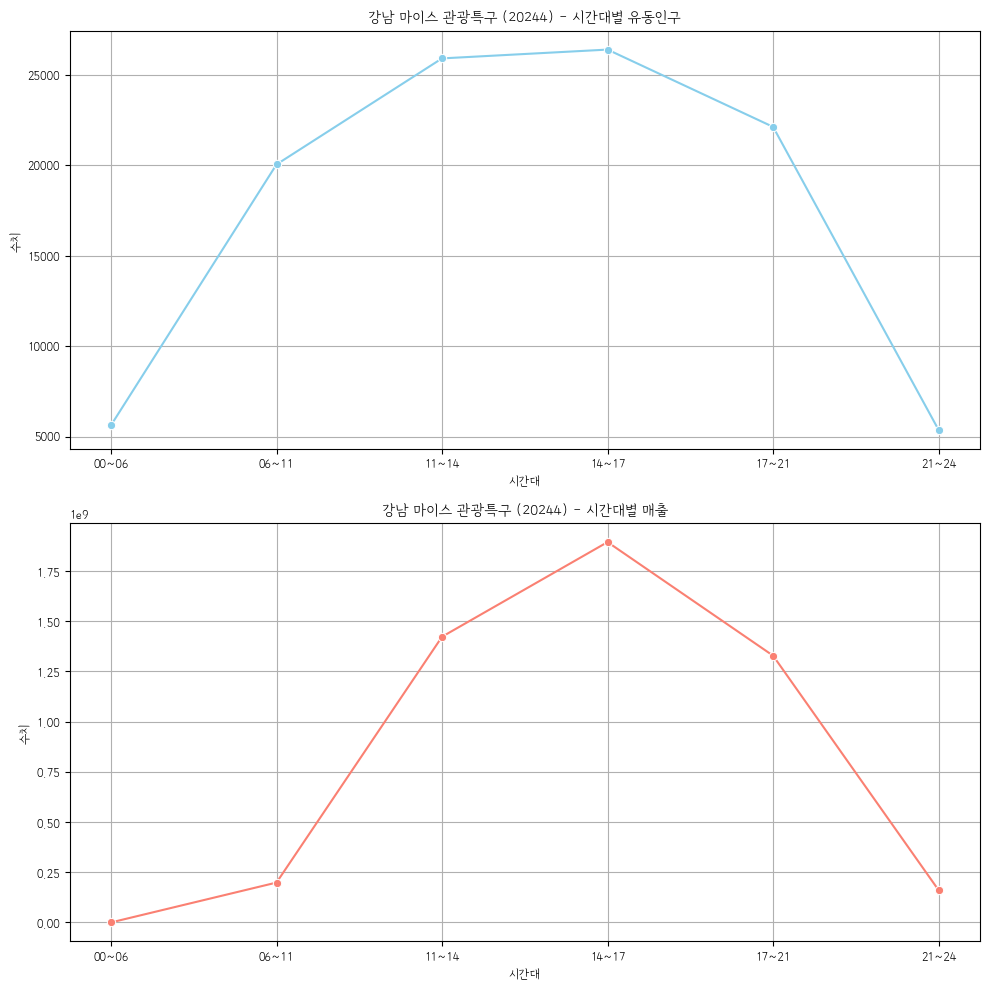

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 대상 상권
target_code = 3001496  # 실제 상권 코드로 교체
data_plot = merged_time[merged_time['상권_코드'] == target_code]

if data_plot.empty:
    print(f"{target_code} 상권에 해당하는 데이터가 없습니다.")
else:
    # 최근 분기 데이터 선택
    row = data_plot.sort_values('기준_년분기_코드', ascending=False).iloc[0]

    # 시간대 정보
    time_slots = ['00~06', '06~11', '11~14', '14~17', '17~21', '21~24']
    population_cols = [f"{t}_유동인구" for t in time_slots]
    sales_cols = [f"{t}_매출" for t in time_slots]

    # 데이터 프레임 생성
    df_pop = pd.DataFrame({
        '시간대': time_slots,
        '수치': [row[col] for col in population_cols]
    })

    df_sales = pd.DataFrame({
        '시간대': time_slots,
        '수치': [row[col] for col in sales_cols]
    })

    # 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    sns.lineplot(data=df_pop, x='시간대', y='수치', marker='o', ax=axes[0], color='skyblue')
    axes[0].set_title(f"{row['상권_코드_명']} ({row['기준_년분기_코드']}) - 시간대별 유동인구")
    axes[0].grid(True)

    sns.lineplot(data=df_sales, x='시간대', y='수치', marker='o', ax=axes[1], color='salmon')
    axes[1].set_title(f"{row['상권_코드_명']} ({row['기준_년분기_코드']}) - 시간대별 매출")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 결론:
    # 비슷하기는 하나, 매출과 유동인구가 완전히 연결된다고 보기는 어렵다
